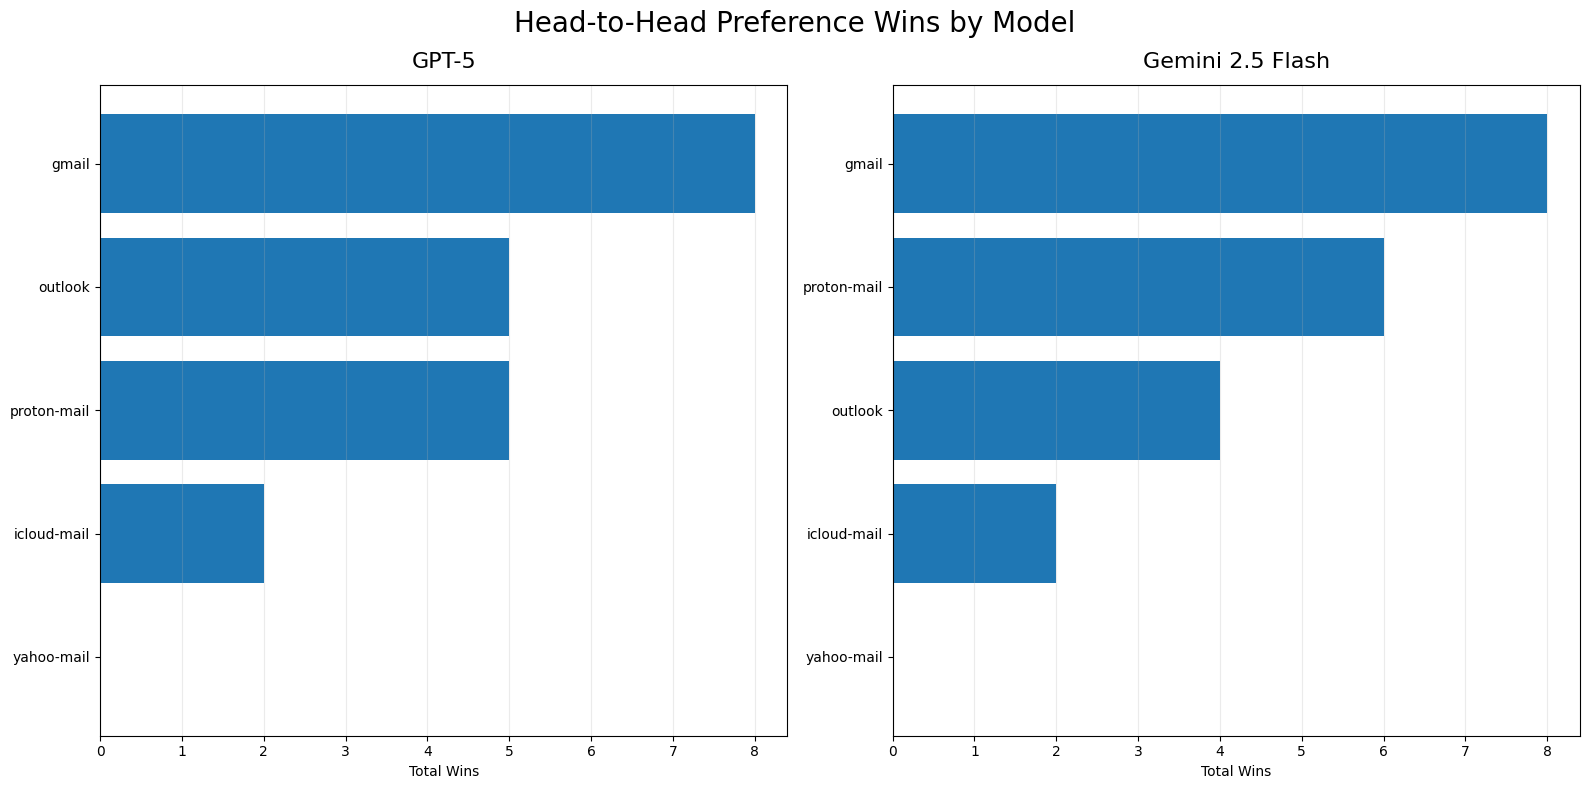

In [4]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gemini.parquet"


def load_wins(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "num_wins")
        .with_columns(pl.col("value").cast(pl.Int64).alias("wins"))
        .group_by("entity_name")
        .agg(pl.col("wins").sum())
        .sort("wins")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_wins(gpt_path)
gemini = load_wins(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

axes[0].barh(gpt["entity"], gpt["wins"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Total Wins")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(gemini["entity"], gemini["wins"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Total Wins")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle("Head-to-Head Preference Wins by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()